# **DataLake - Jogos Olímpicos**
### **Datasets:**

Histórico das Olimpíadas (1896–2022):

https://basedosdados.org/dataset/62f8cb83-ac37-48be-874b-b94dd92d3e2b

Paris 2024 Olympic Summer Games:

https://www.kaggle.com/datasets/piterfm/paris-2024-olympic-summer-games/data

### **Estrutura base + camada Raw**

In [2]:
# =========================================
# 1. IMPORTS
# =========================================
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# =========================================
# 2. ESTRUTURA DO DATA LAKE
# =========================================
BASE_DIR = "olympics-datalake"

paths = [
    f"{BASE_DIR}/raw",
    f"{BASE_DIR}/bronze",
    f"{BASE_DIR}/gold/analise_medalhas",
    f"{BASE_DIR}/gold/analise_modalidades",
    f"{BASE_DIR}/gold/analise_genero"
]

for path in paths:
    os.makedirs(path, exist_ok=True)

print("Estrutura criada!")

# =========================================
# 3. FUNÇÃO PARA METADATA
# =========================================
def create_metadata(name, source, description, fields, path):
    metadata = {
        "nome_dataset": name,
        "fonte": source,
        "descricao": description,
        "campos": fields,
        "data_criacao": str(datetime.now()),
        "observacoes": ""
    }

    with open(path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=4, ensure_ascii=False)

# =========================================
# 4. CARREGAR DATASETS
# =========================================
raw_path = f"{BASE_DIR}/raw"

datasets = {
    "atletas_1896_2022": "atletas_1896_2022.csv",
    "atletas_2024": "atletas_summer_2024.csv",
    "medalhas_1896_2022": "medalhas_1896_2022.csv",
    "medalhas_2024": "medalhas_summer_2024.csv",
    "modalidades_1896_2022": "modalidades_1896_2022.csv",
    "modalidades_2024": "modalidades_summer_2024.csv"
}

dfs = {}

for name, file in datasets.items():
    path = os.path.join(raw_path, file)
    dfs[name] = pd.read_csv(path)

    create_metadata(
        name=name,
        source="Dados Olímpicos",
        description=f"Dataset {name}",
        fields=list(dfs[name].columns),
        path=os.path.join(raw_path, f"{name}.json")
    )

print("Datasets carregados + metadata RAW criado!")

Estrutura criada!
Datasets carregados + metadata RAW criado!


/tmp/ipykernel_8756/3787943716.py:62: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs[name] = pd.read_csv(path)


### **Camada Bronze**

In [3]:
# =========================================
# 5. PROCESSAMENTO (BRONZE)
# =========================================

# --- Padronizar medalhas ---
medalhas_old = dfs["medalhas_1896_2022"]
medalhas_new = dfs["medalhas_2024"]

medalhas_new = medalhas_new.rename(columns={
    "country_code": "country_noc",
    "Gold Medal": "gold",
    "Silver Medal": "silver",
    "Bronze Medal": "bronze",
    "Total": "total"
})

medalhas_new["year"] = 2024

medalhas = pd.concat([medalhas_old, medalhas_new], ignore_index=True)

# --- Atletas ---
atletas_old = dfs["atletas_1896_2022"]
atletas_new = dfs["atletas_2024"]

atletas_new = atletas_new.rename(columns={
    "code": "athlete_id",
    "gender": "sex"
})

atletas = pd.concat([atletas_old, atletas_new], ignore_index=True)

# --- Modalidades ---
modalidades_old = dfs["modalidades_1896_2022"]
modalidades_new = dfs["modalidades_2024"]

modalidades_new["year"] = 2024

modalidades = modalidades_old.copy()

# =========================================
# 6. SALVAR PARQUET (BRONZE)
# =========================================
bronze_path = f"{BASE_DIR}/bronze"

medalhas.to_parquet(f"{bronze_path}/medalhas.parquet")
atletas.to_parquet(f"{bronze_path}/atletas.parquet")
modalidades.to_parquet(f"{bronze_path}/modalidades.parquet")

# metadata bronze
create_metadata("medalhas", "integração", "Medalhas unificadas", list(medalhas.columns),
                f"{bronze_path}/medalhas.json")

create_metadata("atletas", "integração", "Atletas unificados", list(atletas.columns),
                f"{bronze_path}/atletas.json")

create_metadata("modalidades", "integração", "Modalidades", list(modalidades.columns),
                f"{bronze_path}/modalidades.json")

print("Bronze criado!")

# =========================================
# 7. INTEGRAÇÃO (JOIN)
# =========================================

# Exemplo: atletas por país
atletas_por_pais = atletas.groupby("country_noc").size().reset_index(name="qtd_atletas")

# juntar com medalhas
medalhas_join = medalhas.merge(atletas_por_pais, on="country_noc", how="left")

medalhas_join.to_parquet(f"{bronze_path}/medalhas_com_atletas.parquet")

create_metadata(
    "medalhas_com_atletas",
    "join",
    "Medalhas + quantidade de atletas",
    list(medalhas_join.columns),
    f"{bronze_path}/medalhas_com_atletas.json"
)

print("JOIN realizado!")

Bronze criado!
JOIN realizado!


### **Camada Gold**

Gold medalhas pronto!
Gold gênero pronto!
Gold modalidades pronto!


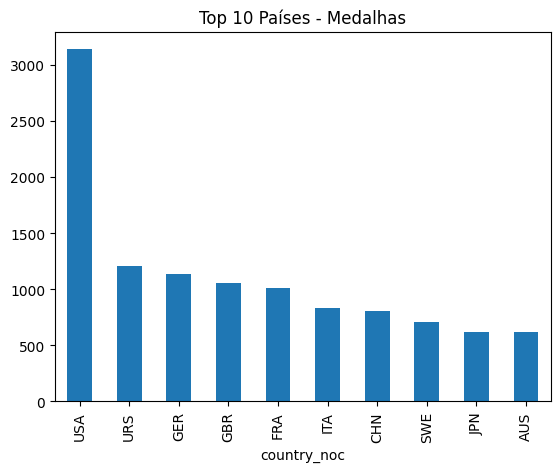

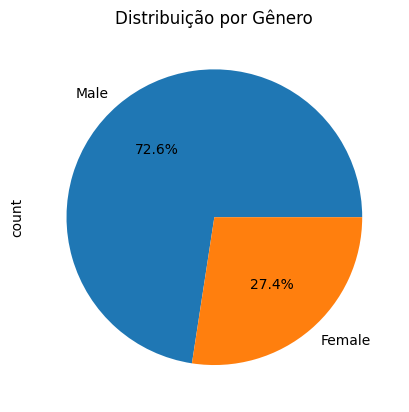

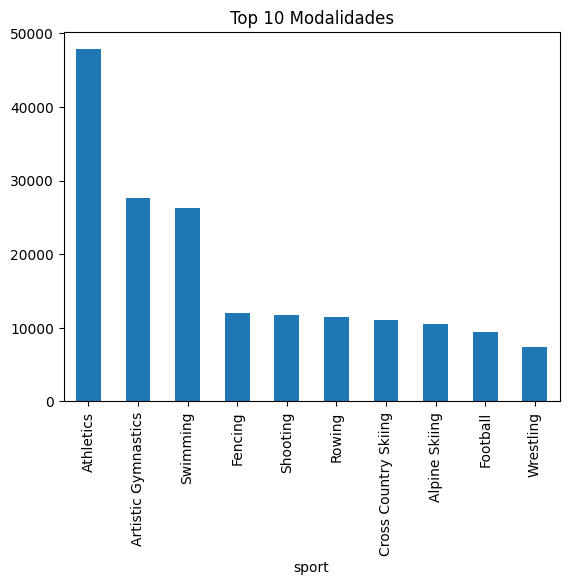

In [4]:
# =========================================
# 8. GOLD - ANÁLISE MEDALHAS
# =========================================
gold_path = f"{BASE_DIR}/gold/analise_medalhas"

summary = medalhas.groupby("country_noc")[["gold", "silver", "bronze"]].sum()
summary["total"] = summary.sum(axis=1)
summary = summary.sort_values("total", ascending=False).head(10)

summary.to_csv(f"{gold_path}/medalhas_summary.csv")

# gráfico
plt.figure()
summary["total"].plot(kind="bar")
plt.title("Top 10 Países - Medalhas")
plt.savefig(f"{gold_path}/medalhas_plot.png")

# metadata gold
create_metadata(
    "analise_medalhas",
    "processamento",
    "Top 10 países por medalhas",
    list(summary.columns),
    f"{gold_path}/metadata.json"
)

print("Gold medalhas pronto!")

# =========================================
# 9. GOLD - GÊNERO
# =========================================
gender_path = f"{BASE_DIR}/gold/analise_genero"

genero = atletas["sex"].value_counts()
genero.to_csv(f"{gender_path}/genero.csv")

plt.figure()
genero.plot(kind="pie", autopct='%1.1f%%')
plt.title("Distribuição por Gênero")
plt.savefig(f"{gender_path}/genero.png")

create_metadata(
    "analise_genero",
    "processamento",
    "Distribuição de atletas por gênero",
    list(genero.index),
    f"{gender_path}/metadata.json"
)

print("Gold gênero pronto!")

# =========================================
# 10. GOLD - MODALIDADES
# =========================================
modalidade_path = f"{BASE_DIR}/gold/analise_modalidades"

# esportes mais frequentes
top_sports = modalidades_old["sport"].value_counts().head(10)
top_sports.to_csv(f"{modalidade_path}/top_modalidades.csv")

plt.figure()
top_sports.plot(kind="bar")
plt.title("Top 10 Modalidades")
plt.savefig(f"{modalidade_path}/modalidades_plot.png")

create_metadata(
    "analise_modalidades",
    "processamento",
    "Modalidades mais frequentes",
    list(top_sports.index),
    f"{modalidade_path}/metadata.json"
)

print("Gold modalidades pronto!")

### **Catálogo do Data Lake**

In [6]:
# =========================================
# 11. DATA CATALOG (metadata_schema.json)
# =========================================

catalog = {
    "data_lake": "Olympics Data Lake",
    "camadas": {
        "raw": [],
        "bronze": [],
        "gold": []
    },
    "data_criacao": str(datetime.now())
}

def scan_metadata(folder, camada):
    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.endswith(".json"):
                path = os.path.join(root, file)

                try:
                    with open(path, "r", encoding="utf-8") as f:
                        meta = json.load(f)

                        catalog["camadas"][camada].append({
                            "arquivo": file,
                            "caminho": path,
                            "nome_dataset": meta.get("nome_dataset", ""),
                            "descricao": meta.get("descricao", ""),
                            "campos": meta.get("campos", [])
                        })
                except:
                    pass

# varrer camadas
scan_metadata(f"{BASE_DIR}/raw", "raw")
scan_metadata(f"{BASE_DIR}/bronze", "bronze")
scan_metadata(f"{BASE_DIR}/gold", "gold")

# salvar catálogo
catalog_path = f"{BASE_DIR}/metadata_schema.json"

with open(catalog_path, "w", encoding="utf-8") as f:
    json.dump(catalog, f, indent=4, ensure_ascii=False)

print("📚 metadata_schema.json criado automaticamente!")

📚 metadata_schema.json criado automaticamente!


In [7]:
# compactar a pasta inteira
!zip -r olympics-datalake.zip olympics-datalake

from google.colab import files
files.download("olympics-datalake.zip")

  adding: olympics-datalake/ (stored 0%)
  adding: olympics-datalake/bronze/ (stored 0%)
  adding: olympics-datalake/bronze/medalhas.parquet (deflated 41%)
  adding: olympics-datalake/bronze/medalhas_com_atletas.json (deflated 50%)
  adding: olympics-datalake/bronze/atletas.parquet (deflated 13%)
  adding: olympics-datalake/bronze/atletas.json (deflated 64%)
  adding: olympics-datalake/bronze/modalidades.json (deflated 50%)
  adding: olympics-datalake/bronze/medalhas.json (deflated 48%)
  adding: olympics-datalake/bronze/modalidades.parquet (deflated 18%)
  adding: olympics-datalake/bronze/medalhas_com_atletas.parquet (deflated 39%)
  adding: olympics-datalake/raw/ (stored 0%)
  adding: olympics-datalake/raw/modalidades_summer_2024.csv (deflated 92%)
  adding: olympics-datalake/raw/medalhas_1896_2022.csv (deflated 85%)
  adding: olympics-datalake/raw/medalhas_1896_2022.json (deflated 48%)
  adding: olympics-datalake/raw/atletas_1896_2022.csv (deflated 70%)
  adding: olympics-datalake/r

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>